### DSCI 410L Project data cleaning

# 1
Load the data files

In [382]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

# MCSLC

In [129]:
#read file
mcslc = pd.read_csv("MCSLC.csv")
#subsection the DF to only necessary columns
mcslc_clean = mcslc[["ID", "City", "Dispatch Date & Time", "Disposition"]].dropna()

#Clean closed_as column
mcslc_clean = mcslc_clean.rename(columns={"Disposition": "closed_as"}) #renaming the disposition column for consistancy between dataframes
mcslc_clean["closed_as"] = mcslc_clean["closed_as"].str.upper()
#change cmergency department labal to HOSPITAL
mcslc_clean.replace('EMERGENCY DEPARTMENT', 'HOSPITAL', inplace=True)


#Clean City Column
mcslc_clean.drop(mcslc_clean[mcslc_clean["City"].isin(["Unknown", "Other", "Out of County"])].index, inplace=True)

#Change the datetime column to actual datetime variables
mcslc_clean["calltime"]= pd.to_datetime(mcslc_clean["Dispatch Date & Time"], format="%m/%d/%y %H:%M")

#Agency column
mcslc_clean["agency"] = "MCSLC"

mcslc_eug = mcslc_clean.where(mcslc_clean["City"] == "Eugene").dropna()
mcslc_spd = mcslc_clean.where(mcslc_clean["City"] == "Springfield").dropna()

mcslc_spd.head()

,ID,City,Dispatch Date & Time,closed_as,calltime,agency
33,14472.0,Springfield,11/4/25 5:42,HOSPITAL,2025-11-04 05:42:00,MCSLC
39,12245.0,Springfield,8/22/24 0:00,HOSPITAL,2024-08-22 00:00:00,MCSLC
48,10052.0,Springfield,1/14/25 15:04,HOSPITAL,2025-01-14 15:04:00,MCSLC
49,10062.0,Springfield,1/16/25 15:19,HOSPITAL,2025-01-16 15:19:00,MCSLC
51,10070.0,Springfield,2/1/25 16:31,HOSPITAL,2025-02-01 16:31:00,MCSLC


# Eugene


In [ ]:
url = "C:/Users/brook/OneDrive/Desktop/DSCI 410L/Eugene_CAD_data_noloc/*.csv"
files = glob.glob(url)
eug = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
eug.head(3)

C:\Users\brook\AppData\Local\Temp\ipykernel_18448\1743683478.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  eug = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
C:\Users\brook\AppData\Local\Temp\ipykernel_18448\1743683478.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  eug = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)


,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month
0,2015,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,PERSON STOP,ASST,ASSISTED,0.0,0.0,217,1,1,6,_5E48,1,1,NaN
1,2015,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,FIGHT,RSLV,RESOLVED,0.0,0.0,2114,1,1,P,_3F65,4,2,NaN
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,_3J79,1,1,NaN


In [227]:
eug_clean = eug[["calltime", "closed_as", "agency", "primeunit"]]
eug_clean = eug_clean.dropna()

#closed_as column
#change to K DEPLOYED maybe K9 units?
eug_clean.replace(['K897 DEPLOYED', 'K891 DEPLOYED', 'K895 DEPLOYED', 'K898 DEPLOYED', 'K896 DEPLOYED', 'K893 DEPLOYED'], "K DEPLOYED", inplace=True)
#assumption this is hospital transport: 'PATIENT TRANSPORTED' and changed to 'HOSPITAL'
eug_clean.replace(["PATIENT TRANSPORTED", 'MEDICAL AID EPD', 'SEND PCR REPORT'], "HOSPITAL", inplace=True)
#should 'JUVENILE TAKEN INTO CUSTODY' count as 'ARREST'?
eug_clean.replace("JUVENILE TAKEN INTO CUSTODY", "ARREST", inplace=True)


#change calltime to datetime objects
eug_clean["calltime"] = pd.to_datetime(eug_clean["calltime"], format="%Y-%m-%d %H:%M:%S.%f")


#Make is_CAHOOTS column
#True if agency==CAHE and/or primeunit follows the pattern _#J##
eug_clean["is_cahoots"] = (eug_clean["agency"] == "CAHE" ) | (eug_clean["primeunit"].isin(['_TESTCA', '_CAHOT ', '_1J77  ', '_3J78  ', '_4J79  ','_AWO   ', '_C100  ', '_3J77  ', '_3J79  ']))
eug_clean.loc[eug_clean["is_cahoots"] == True, "agency"] = "CAHE"
eug_clean.head()

,calltime,closed_as,agency,primeunit,is_cahoots
0,2015-01-01 00:00:00,ASSISTED,EPD,_5E48,False
1,2015-01-01 00:00:44,RESOLVED,EPD,_3F65,False
2,2015-01-01 00:01:05,ASSISTED,CAHE,_3J79,True
3,2015-01-01 00:03:16,PATROL CHECK,EPD,_5E48,False
4,2015-01-01 00:03:34,ADVISED,EPD,_5K97,False


In [ ]:
#Merge Eug and MCSLC
mcslc_eug["is_cahoots"] = False
mcslc_eug.drop(["City", "ID", "Dispatch Date & Time"], axis=1, inplace=True)

eugene = pd.concat([eug_clean, mcslc_eug], ignore_index=True).sort_values(by="calltime")
eugene["yr"] = eugene["calltime"].dt.year
eugene["month"] = eugene["calltime"].dt.month
eugene.head(3)

,calltime,closed_as,agency,primeunit,is_cahoots,yr,month
0,2015-01-01 00:00:00,ASSISTED,EPD,_5E48,False,2015,1
1,2015-01-01 00:00:44,RESOLVED,EPD,_3F65,False,2015,1
2,2015-01-01 00:01:05,ASSISTED,CAHE,_3J79,True,2015,1


# Springfield

In [384]:
#Read in all files
spd = pd.read_excel("2015-2025 SPD Calls for Service.xlsx")
spd_units = pd.read_excel("2015-2025 SPD Responding Units.xlsx")
spd_close = pd.read_excel("2015-2025 SPD Calls with Close Codes.xlsx")
designator = pd.read_csv("SPD Designator Notes.csv")
close_codes = pd.read_csv("SPD Close Codes.csv")

#Merge dataframes
spd_new = spd.merge(spd_close, on="Incident Number", how="outer")
spd_new = spd_new.merge(spd_units, left_on="Incident Number", right_on="inci id", how="outer")

spd_clean = spd_new[['Responding Agency', 'Close Code', 'call time', 'prime unit', 'Call Year']].copy()
spd_clean.rename(columns={"Responding Agency": "agency"}, inplace=True)

mapping = dict(zip(close_codes["Close Code"], close_codes["Definition"]))
spd_clean["closed_as"] = (spd_clean["Close Code"].map(mapping))
spd_clean["closed_as"] = spd_clean["closed_as"].str.upper()

#convert to datetime
#spd_clean["calltime"] = pd.to_datetime(spd_clean["call time"], format="%m/%d/%Y %H:%M")
spd_clean["calltime"] = pd.to_datetime(spd_clean["call time"], errors="coerce")
spd_clean["yr"] = spd_clean["calltime"].dt.year
spd_clean["month"] = spd_clean["calltime"].dt.month
spd_clean.drop(["Close Code", "call time"], axis=1, inplace=True)

#create is_cahoots boolean column
spd_clean["is_cahoots"] = spd_clean["prime unit"].isin(['3J81  ', 'CAHOT ', '3J78  '])
spd_clean.loc[spd_clean["is_cahoots"] == True, "agency"] = "CAHE"


#updating closed as variables similar to eugene
spd_clean.replace(['MEDICAL AID EPD', 'MED EXPRESS', 'PATIENT TRASNPORTED', 'SEND PCR REPORT'], "HOSPITAL", inplace=True)
spd_clean.replace("JUVENILE TAKEN INTO CUSTODY", "ARREST", inplace=True)

spd_clean.head(5)


,agency,prime unit,Call Year,closed_as,calltime,yr,month,is_cahoots
0,SPD,1S12,2015,ASSISTED,2015-01-01 00:01:00,2015,1,False
1,SPD,,2015,DISREGARD,2015-01-01 00:04:00,2015,1,False
2,SPD,3S12,2015,ARREST,2015-01-01 00:11:00,2015,1,False
3,SPD,1S12,2015,TRAFFIC STOP ONLY,2015-01-01 00:14:00,2015,1,False
4,SPD,1S18,2015,TRAFFIC STOP ONLY,2015-01-01 00:17:00,2015,1,False


In [388]:
spd_clean["yr"].unique()

array([2015], dtype=int32)

In [ ]:
#Merge MCSLC and Springfield
#mcslc_spd.drop(["City", "Dispatch Date & Time", "ID"], axis=1, inplace=True)
mcslc_spd["is_cahoots"] = False
springfield = (pd.concat([spd_clean, mcslc_spd], ignore_index=True).sort_values(by="calltime"))
#springfield.drop(["inci id"], axis=1, inplace=True)
springfield.head(3)


,agency,prime unit,closed_as,calltime,yr,month,is_cahoots
0,SPD,1S12,ASSISTED,2015-01-01 00:01:00,2015.0,1.0,False
1,SPD,,DISREGARD,2015-01-01 00:04:00,2015.0,1.0,False
2,SPD,3S12,ARREST,2015-01-01 00:11:00,2015.0,1.0,False


### ANALYTICAL STEPS

*step 1*:

Exploratory analysis: Using pandas compute general frequencies of each variable in the closed_as column. Specifically focus on hospital transportations and arrests as well as splitting frequencies by agency and normalizing those counts. Finally, compare change over time of hospital and arrest outcomes.  It’s important to mark at least roughly where MCSLC started activities in Eugene and when CAHOOTS stopped services because these are our main points of interest in time to measure if there has been a difference between agencies. 

**Eugene**

In [ ]:
#Eugene exploration of Hospital
eug_hospital = eugene[eugene["closed_as"] == "HOSPITAL"] #closed as sign only hospital

def statements (df, st):
    '''
    This function is Generalizing the calculations for the different agencies. 
    Takes a dataframe (df) which should have columns [calltime, closed_as, agency, is_cahoots]
    and st which is a string which should describe what is being calculated.
    It returns nothing but prints three statements. 
    '''
    total_l = len(df) #total length 

    cah = sum(df["is_cahoots"]) #how mant hospital were also by cahoots
    time_range = df["calltime"].max() - df["calltime"].min() #range of calltime
    percent = round((cah / total_l )*100, 2)
    print(f"In {time_range} there were {cah} / {total_l} {st} completed by CAHOOTS this is {percent}%")

    mc = len(df[df["agency"] == "MCSLC"]) #length where agency was mcslc
    per_mc = round((mc / total_l) *100, 2) 
    print(f"The number of {st} made by MCSLC was {mc} which is {per_mc}%")
    epd = total_l - (cah + mc) #epd hospital closed as
    per_ep = round((epd / total_l) *100, 2)
    print(f"The number of {st} by EPD was {epd} or {per_ep}%")
    return 

statements(eug_hospital, "hospital transportations")

In 3975 days 11:24:06 there were 22 / 574 hospital transportations completed by CAHOOTS this is 3.83%
The number of hospital transportations made by MCSLC was 482 which is 83.97%
The number of hospital transportations by EPD was 70 or 12.2%


In [ ]:
year = 2015
for i in range(11):
    temp_yr = eug_hospital[eug_hospital["yr"] == year]
    #should do the same as the function above but per year
    str_yr = str(year)
    statements(temp_yr, "hospital transportations in "+str_yr)
    print("\n")
    year += 1

In 0 days 00:00:00 there were 0 / 1 hospital transportations in 2015 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2015 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2015 by EPD was 1 or 100.0%


In 170 days 20:14:53 there were 6 / 10 hospital transportations in 2016 completed by CAHOOTS this is 60.0%
The number of hospital transportations in 2016 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2016 by EPD was 4 or 40.0%


In 297 days 21:21:06 there were 3 / 15 hospital transportations in 2017 completed by CAHOOTS this is 20.0%
The number of hospital transportations in 2017 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2017 by EPD was 12 or 80.0%


In 208 days 02:03:52 there were 2 / 7 hospital transportations in 2018 completed by CAHOOTS this is 28.57%
The number of hospital transportations in 2018 made by MCSLC was 0 which is 0.0%
The number of hospital transportation

C:\Users\brook\AppData\Local\Temp\ipykernel_18448\3241837619.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eug_hosp_mc = len(df[eug_hospital["agency"] == "MCSLC"]) #length where agency was mcslc
C:\Users\brook\AppData\Local\Temp\ipykernel_18448\3241837619.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eug_hosp_mc = len(df[eug_hospital["agency"] == "MCSLC"]) #length where agency was mcslc
C:\Users\brook\AppData\Local\Temp\ipykernel_18448\3241837619.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eug_hosp_mc = len(df[eug_hospital["agency"] == "MCSLC"]) #length where agency was mcslc
C:\Users\brook\AppData\Local\Temp\ipykernel_18448\3241837619.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eug_hosp_mc = len(df[eug_hospital["agency"] == "MCSLC"]) #length where agency was mcslc
C:\Users\brook\AppData\Local\Temp\ipykernel_18448\3241837619.py:

In [ ]:
#Eugene exploration of Arrest
eug_arrest = eugene[eugene["closed_as"] == "ARREST"]
statements(eug_arrest, "arrests")
print("\n")

year = 2015
for i in range(11):
    temp_yr = eug_arrest[eug_arrest["yr"] == year]
    #should do the same as the function above but per year
    str_yr = str(year)
    statements(temp_yr, "hospital transportations in "+str_yr)
    print("\n")
    year += 1

In 4017 days 22:41:11 there were 3 / 40607 arrests completed by CAHOOTS this is 0.01%
The number of arrests made by MCSLC was 12 which is 0.03%
The number of arrests by EPD was 40592 or 99.96%


In 364 days 23:22:17 there were 0 / 3771 hospital transportations in 2015 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2015 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2015 by EPD was 3771 or 100.0%


In 365 days 20:47:20 there were 0 / 4009 hospital transportations in 2016 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2016 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2016 by EPD was 4009 or 100.0%


In 364 days 23:44:58 there were 0 / 4006 hospital transportations in 2017 completed by CAHOOTS this is 0.0%
The number of hospital transportations in 2017 made by MCSLC was 0 which is 0.0%
The number of hospital transportations in 2017 by EPD was 4006 or 100.0%


In 364 days 2

2024-08-18 00:00:00 2025-12-31 12:28:18


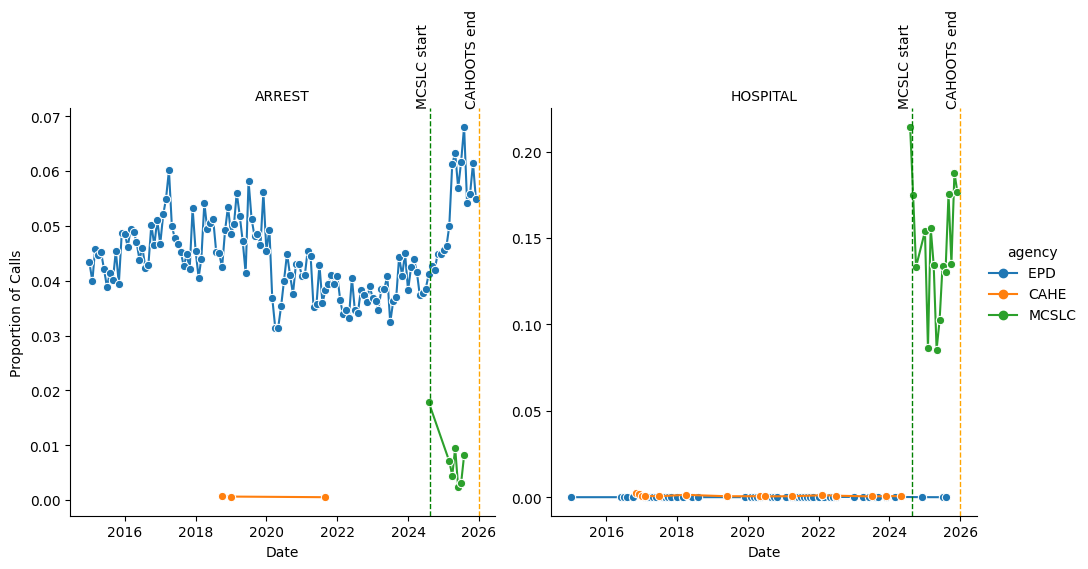

In [ ]:
#visual respresentation of hospital and arrest by year and agency
mcslc_start = min(eugene[eugene["agency"] == "MCSLC"]["calltime"])
cahoots_end =  max(eugene[eugene["is_cahoots"] == True]["calltime"])
eugene["month_date"] = eugene["calltime"].dt.to_period("M").dt.to_timestamp()

print("Eugene")
#sub group of just hospital or arrest
sub = eugene[eugene["closed_as"].isin(["ARREST", "HOSPITAL"])]

#count by year and agency
counts = (sub.groupby(["month_date", "agency", "closed_as"]).size().reset_index(name="count")).fillna(0)
totals = eugene.groupby(["month_date", "agency"]).size().reset_index(name="total")
counts = counts.merge(totals, on=["month_date", "agency"])
counts["rate"] = counts["count"] / counts["total"]

#plot
g = sns.relplot(
    data=counts,
    x="month_date",
    y="rate",              
    hue="agency",
    col="closed_as",
    kind="line",
    marker="o",
    facet_kws={"sharey": False}
)

g.set_axis_labels("Date", "Proportion of Calls")
g.set_titles("{col_name}")

#plotting vertical lines for mcslc start and cahoots end
for ax in g.axes.flat:
    ax.axvline(mcslc_start, color="green", linestyle="--", linewidth=1)
    ax.axvline(cahoots_end, color="orange", linestyle="--", linewidth=1)

    ymax = ax.get_ylim()[1]

    ax.text(mcslc_start, ymax, "MCSLC start",
            rotation=90, va="bottom", ha="right")

    ax.text(cahoots_end, ymax, "CAHOOTS end",
            rotation=90, va="bottom", ha="right")


**springfield**

In [389]:
s_hosp = springfield[springfield["closed_as"] == "HOSPITAL"]
s_arr = springfield[springfield["closed_as"] == "ARREST"]
statements(s_hosp, "Springfield Hospital Transportations")
print("\n")
statements(s_arr, "springfield arrests")

In 3998 days 09:38:00 there were 0 / 175 Springfield Hospital Transportations completed by CAHOOTS this is 0.0%
The number of Springfield Hospital Transportations made by MCSLC was 72 which is 41.14%
The number of Springfield Hospital Transportations by EPD was 103 or 58.86%


In 363 days 23:37:00 there were 0 / 3106 springfield arrests completed by CAHOOTS this is 0.0%
The number of springfield arrests made by MCSLC was 0 which is 0.0%
The number of springfield arrests by EPD was 3106 or 100.0%


Springfield


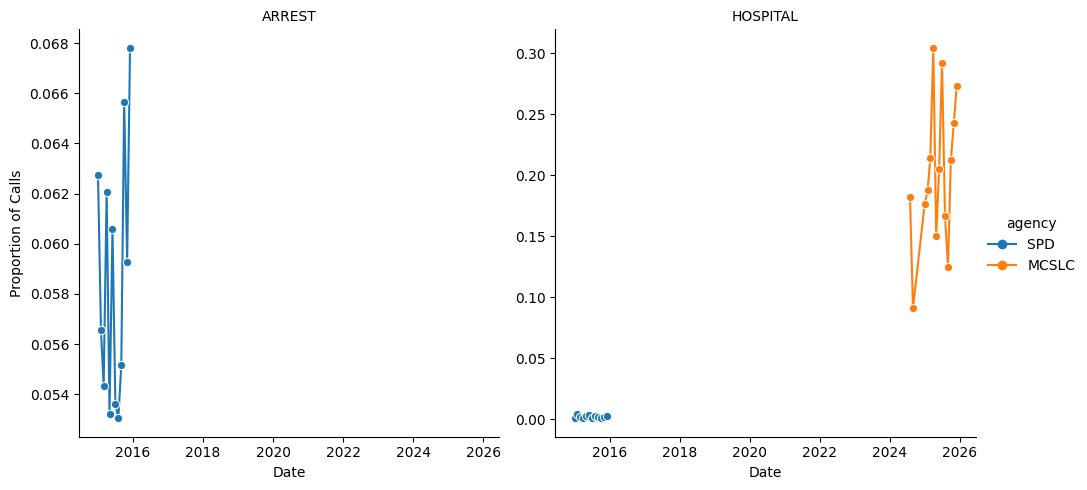

In [390]:
#visual respresentation of hospital and arrest by year and agency
springfield["month_date"] = springfield["calltime"].dt.to_period("M").dt.to_timestamp()

print("Springfield")
#sub group of just hospital or arrest
sub = springfield[springfield["closed_as"].isin(["ARREST", "HOSPITAL"])]

#count by year and agency
counts = (sub.groupby(["month_date", "agency", "closed_as"]).size().reset_index(name="count")).fillna(0)
totals = springfield.groupby(["month_date", "agency"]).size().reset_index(name="total")
counts = counts.merge(totals, on=["month_date", "agency"])
counts["rate"] = counts["count"] / counts["total"]

#plot
g = sns.relplot(
    data=counts,
    x="month_date",
    y="rate",              
    hue="agency",
    col="closed_as",
    kind="line",
    marker="o",
    facet_kws={"sharey": False}
)

g.set_axis_labels("Date", "Proportion of Calls")
g.set_titles("{col_name}")

**Overall change in hospital or arrest outcomes by city**

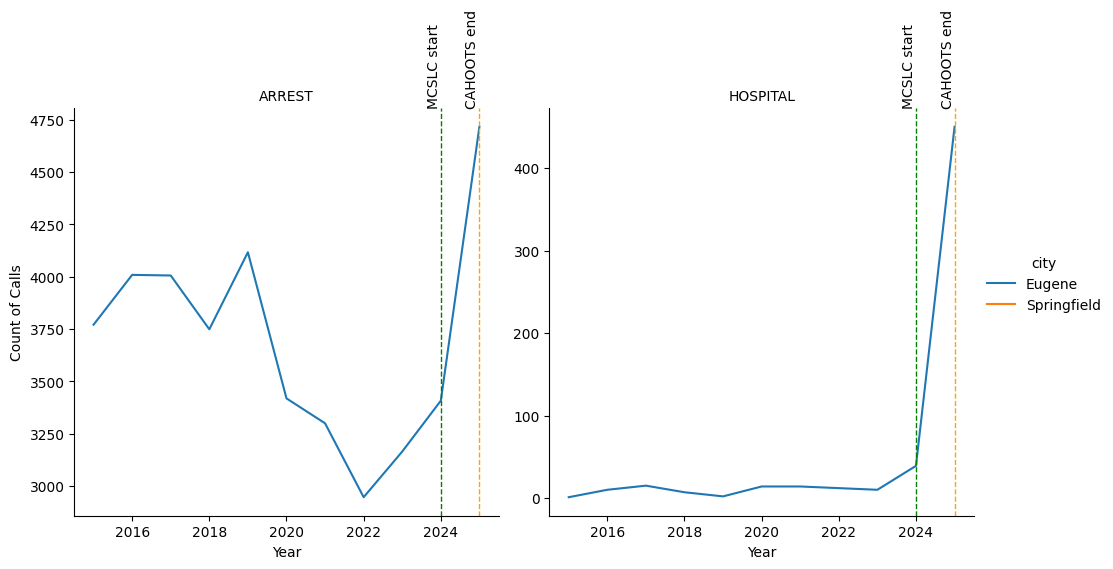

In [391]:
#create two dataframes one for eug and one for springfield
e = eugene[eugene["closed_as"].isin(["ARREST", "HOSPITAL"])]
s = springfield[springfield["closed_as"].isin(["ARREST", "HOSPITAL"])]

#calculate the counts by year
e_counts = (e.groupby(["yr", "closed_as"]).size().reset_index(name="count"))
s_counts = (s.groupby(["yr", "closed_as"]).size().reset_index(name="count"))

#add city label column
e_counts["city"] = "Eugene"
s_counts["city"] = "Springfield"
#combine the new dataframes
ttl_counts = pd.concat([e_counts, s_counts])

mcslc_start_year = mcslc_start.year
cahoots_end_year = cahoots_end.year

#plot
p = sns.relplot(data=ttl_counts, 
             x="yr", 
             y="count", 
             hue="city", 
             col="closed_as", 
             kind="line",
             facet_kws={"sharey": False})
p.set_axis_labels("Year", "Count of Calls")
p.set_titles("{col_name}")
#plotting vertical lines for mcslc start and cahoots end
for ax in p.axes.flat:
    ax.axvline(mcslc_start_year, color="green", linestyle="--", linewidth=1)
    ax.axvline(cahoots_end_year, color="orange", linestyle="--", linewidth=1)

    ymax = ax.get_ylim()[1]

    ax.text(mcslc_start_year, ymax, "MCSLC start",
            rotation=90, va="bottom", ha="right")

    ax.text(cahoots_end_year, ymax, "CAHOOTS end",
            rotation=90, va="bottom", ha="right")
